# Soft Skills Modeling

---

## Objective

This notebook builds a **soft-skills scoring and modeling pipeline** that:
1. Fuses **audio** and **video-derived behavioral features**
2. Computes **interpretable soft-skill scores (0–100)**
3. **Validates** those scores statistically and visually
4. Trains and evaluates **regression models** to predict each soft skill
5. Selects **best-performing, well-generalizing models** per skill

The output is designed for **CV / interview-video evaluation** and downstream **job-matching systems**.

---

## Data Sources

| Source | Description | Examples |
|------|------------|----------|
| Audio features | Prosodic & speech metrics | loudness, pauses, fillers, WPM |
| Video features | Human-extracted non-verbal cues | posture, eye focus, smiling |

Both datasets are merged on a common `id`.



In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneOut, cross_val_score, cross_val_predict, learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [4]:
import pandas as pd
# Load audio features
audio_df = pd.read_csv('audioExtractedFeatures.csv')
print(f"Audio data: {audio_df.shape[0]} samples, {audio_df.shape[1]} features")

# Load video features
video_df = pd.read_csv('soft-skills-cnn-transformed.csv')
print(f"Video data: {video_df.shape[0]} samples, {video_df.shape[1]} features")

Audio data: 32 samples, 15 features
Video data: 32 samples, 6 features


## Preprocessing

### Ordinal Encoding
Categorical visual labels (`a,b,c`) are mapped to numeric ordinal values (0–2).

In [5]:
# Convert ordinal labels to numbers (a=0, b=1, c=2)
ordinal_mapping = {'a': 0, 'b': 1, 'c': 2}
categorical_cols = ['head_tilts_class(0-2)', 'eye_focus_class(0-2)',
                    'smiling_class(0-2)', 'posture_class(0-2)']

for col in categorical_cols:
    video_df[f"{col}_numeric"] = video_df[col].map(ordinal_mapping)

# Merge datasets
audio_df['id'] = pd.to_numeric(audio_df['filename'], errors='coerce')
video_df['id'] = pd.to_numeric(video_df['id'], errors='coerce')

merged_df = pd.merge(audio_df, video_df, on='id', how='inner').sort_values('id')
print(f"\nMerged dataset: {merged_df.shape[0]} samples, {merged_df.shape[1]} features")


Merged dataset: 32 samples, 25 features


In [6]:
merged_df.columns

Index(['filename', 'duration_sec', 'loudness_mean', 'loudness_std',
       'noisiness_mean', 'noisiness_std', 'brightness_mean', 'brightness_std',
       'silence_ratio', 'speech_ratio', 'pause_count', 'long_pause_count',
       'long_pause_total_sec', 'long_pause_max_sec', 'words_per_min', 'id',
       'no_of_filler_words', 'head_tilts_class(0-2)', 'eye_focus_class(0-2)',
       'smiling_class(0-2)', 'posture_class(0-2)',
       'head_tilts_class(0-2)_numeric', 'eye_focus_class(0-2)_numeric',
       'smiling_class(0-2)_numeric', 'posture_class(0-2)_numeric'],
      dtype='object')

### Normalization Strategy

| Feature Type | Method | Range |
|-------------|--------|-------|
| Continuous audio features | Min–Max Scaling | [0,1] |
| Ordinal visual features | Manual scaling | [0,1] |

This ensures **feature comparability** without destroying ordinal meaning.

In [7]:
def normalize_features(df):
    normalized_df = df.copy()

    # Continuous features - use Min-Max scaling
    continuous_features = [
        'loudness_mean', 'loudness_std', 'noisiness_mean', 'noisiness_std',
        'brightness_mean', 'brightness_std', 'silence_ratio', 'speech_ratio',
        'pause_count', 'long_pause_count', 'long_pause_total_sec',
        'long_pause_max_sec', 'words_per_min', 'no_of_filler_words', 'duration_sec'
    ]

    scaler = MinMaxScaler()
    normalized_df[continuous_features] = scaler.fit_transform(df[continuous_features])

    # Ordinal features already 0-2, normalize to 0-1
    ordinal_features = [
        'head_tilts_class(0-2)_numeric', 'eye_focus_class(0-2)_numeric',
        'smiling_class(0-2)_numeric', 'posture_class(0-2)_numeric'
    ]

    for col in ordinal_features:
        normalized_df[col] = df[col] / 2.0  # Scale 0-2 to 0-1

    print(f"   Continuous: {len(continuous_features)} features")
    print(f"   Ordinal: {len(ordinal_features)} features")

    return normalized_df

normalized_df = normalize_features(merged_df)

   Continuous: 15 features
   Ordinal: 4 features


## Soft Skill Design

Eight soft skills are computed using **domain-informed weighted formulas**:

| Skill | Core Signals |
|-----|-------------|
| Professionalism | posture, eye focus, low noise |
| Confidence | loudness, posture, fluency |
| Engagement | smiling, brightness, speech ratio |
| Enthusiasm | smiling, loudness, vocal dynamics |
| Communication | fillers (−), pace, clarity |
| Presentation | posture, eye contact, control |
| Clarity of Thought | fillers (−), pauses (−), flow |
| Positivity | smiling, brightness, energy |

### Scoring Logic
- Positive indicators increase the score
- Negative indicators subtract from the score
- Scores are clipped to **[0,100]**
- Final compression centers scores around **50** for interpretability

---

In [8]:
# Domain-based feature selection (3-4 features per skill)
feature_importance = {
    'Professionalism': [
        'eye_focus_class(0-2)_numeric',
        'posture_class(0-2)_numeric',
        'no_of_filler_words',
        'loudness_mean'
    ],
    'Confidence': [
        'eye_focus_class(0-2)_numeric',
        'posture_class(0-2)_numeric',
        'loudness_mean',
        'words_per_min'
    ],
    'Engagement': [
        'smiling_class(0-2)_numeric',
        'eye_focus_class(0-2)_numeric',
        'speech_ratio',
        'brightness_mean'
    ],
    'Enthusiasm': [
        'smiling_class(0-2)_numeric',
        'brightness_mean',
        'loudness_mean',
        'head_tilts_class(0-2)_numeric'
    ],
    'Communication': [
        'no_of_filler_words',
        'words_per_min',
        'eye_focus_class(0-2)_numeric',
        'silence_ratio'
    ],
    'Presentation': [
        'posture_class(0-2)_numeric',
        'eye_focus_class(0-2)_numeric',
        'loudness_mean',
        'noisiness_mean'
    ],
    'Clarity_of_Thought': [
        'no_of_filler_words',
        'words_per_min',
        'noisiness_mean',
        'pause_count'
    ],
    'Positivity': [
        'smiling_class(0-2)_numeric',
        'eye_focus_class(0-2)_numeric',
        'brightness_mean',
        'loudness_mean'
    ]
}

## Feature Selection (Per Skill)

Each soft skill uses **3–4 carefully selected features** to:
- Reduce overfitting
- Improve interpretability
- Match human intuition

Example:

| Skill | Features Used |
|-----|---------------|
| Confidence | loudness, posture, eye focus, WPM |
| Clarity of Thought | fillers, pauses, noisiness |

In [9]:
def calculate_soft_skills_improved(df):
    # First normalize all features
    norm_df = normalize_features(df)

    # Initialize results
    soft_skills = pd.DataFrame(index=df.index)

    # 1. PROFESSIONALISM
    print("\nProfessionalism = Composed + Clear + Minimal distractions")

    # Positive indicators (weighted)
    prof_pos = (
        3.0 * norm_df['posture_class(0-2)_numeric'] +      # Very important
        3.0 * norm_df['eye_focus_class(0-2)_numeric'] +    # Very important
        2.0 * norm_df['loudness_mean'] +                   # Moderate volume
        1.5 * (1 - norm_df['loudness_std']) +              # Consistent volume
        1.0 * norm_df['silence_ratio']                     # Strategic pauses
    )

    # Negative indicators (weighted)
    prof_neg = (
        3.0 * norm_df['no_of_filler_words'] +              # Very unprofessional
        2.5 * norm_df['noisiness_mean'] +                  # Background noise
        2.0 * norm_df['pause_count'] +                     # Too many pauses
        1.5 * norm_df['long_pause_total_sec'] +            # Long awkward pauses
        1.0 * norm_df['brightness_std']                    # Voice inconsistency
    )

    total_weight_prof = 10.5 + 10.0  # Sum of all weights
    soft_skills['Professionalism'] = 100 * (prof_pos - prof_neg) / total_weight_prof

    # 2. CONFIDENCE
    print("Confidence = Strong voice + Good posture + Fluent speech")

    conf_pos = (
        3.0 * norm_df['loudness_mean'] +                   # Strong voice
        3.0 * norm_df['eye_focus_class(0-2)_numeric'] +    # Direct eye contact
        2.5 * norm_df['posture_class(0-2)_numeric'] +      # Upright posture
        2.0 * norm_df['words_per_min'] +                   # Good pace
        1.5 * norm_df['speech_ratio'] +                    # More speech
        1.0 * (1 - norm_df['loudness_std'])                # Consistent voice
    )

    conf_neg = (
        3.0 * norm_df['no_of_filler_words'] +              # Uncertainty
        2.5 * norm_df['long_pause_total_sec'] +            # Hesitation
        2.0 * norm_df['pause_count'] +                     # Frequent pausing
        1.5 * norm_df['noisiness_std']                     # Nervous voice
    )

    total_weight_conf = 13.0 + 9.0
    soft_skills['Confidence'] = 100 * (conf_pos - conf_neg) / total_weight_conf

    # 3. ENGAGEMENT
    print("Engagement = Expressive + Dynamic + Energetic")

    engage_pos = (
        3.5 * norm_df['smiling_class(0-2)_numeric'] +      # Smiling is key
        2.5 * norm_df['speech_ratio'] +                    # Talking more
        2.5 * norm_df['brightness_mean'] +                 # Vocal energy
        2.0 * norm_df['loudness_mean'] +                   # Audible energy
        2.0 * norm_df['eye_focus_class(0-2)_numeric'] +    # Connecting
        1.5 * norm_df['loudness_std'] +                    # Dynamic (variation OK)
        1.0 * norm_df['words_per_min']                     # Good pace
    )

    engage_neg = (
        3.0 * norm_df['silence_ratio'] +                   # Too much silence
        2.0 * norm_df['long_pause_total_sec'] +            # Dead air
        1.0 * (1 - norm_df['posture_class(0-2)_numeric'])  # Slouching = disengaged
    )

    total_weight_engage = 15.0 + 6.0
    soft_skills['Engagement'] = 100 * (engage_pos - engage_neg) / total_weight_engage

    # 4. ENTHUSIASM
    print("Enthusiasm = High energy + Positive affect + Animated")

    enthus_pos = (
        4.0 * norm_df['smiling_class(0-2)_numeric'] +      # Smiling = enthusiasm
        3.0 * norm_df['brightness_mean'] +                 # Bright voice
        3.0 * norm_df['loudness_mean'] +                   # Loud = energetic
        2.5 * norm_df['speech_ratio'] +                    # Lots of talking
        2.0 * norm_df['loudness_std'] +                    # Dynamic voice
        1.5 * norm_df['words_per_min']                     # Fast speech
    )

    enthus_neg = (
        3.0 * norm_df['silence_ratio'] +                   # Silence kills energy
        2.0 * (1 - norm_df['posture_class(0-2)_numeric']) + # Low energy posture
        1.0 * norm_df['noisiness_mean']                    # Monotone
    )

    total_weight_enthus = 16.0 + 6.0
    soft_skills['Enthusiasm'] = 100 * (enthus_pos - enthus_neg) / total_weight_enthus

    # 5. COMMUNICATION
    print("Communication = Clear + Fluent + Well-paced")

    comm_pos = (
        3.5 * norm_df['speech_ratio'] +                    # More speech
        3.0 * (1 - norm_df['no_of_filler_words']) +        # Fluent (invert fillers)
        2.5 * norm_df['words_per_min'] +                   # Good pace
        2.5 * norm_df['eye_focus_class(0-2)_numeric'] +    # Connection
        2.0 * norm_df['posture_class(0-2)_numeric'] +      # Professional stance
        1.5 * (1 - norm_df['noisiness_mean'])              # Clear audio
    )

    comm_neg = (
        3.0 * norm_df['no_of_filler_words'] +              # Disfluency
        2.5 * norm_df['pause_count'] +                     # Choppy speech
        2.0 * norm_df['long_pause_total_sec'] +            # Long gaps
        1.5 * norm_df['noisiness_mean']                    # Unclear audio
    )

    total_weight_comm = 15.0 + 9.0
    soft_skills['Communication'] = 100 * (comm_pos - comm_neg) / total_weight_comm

    # 6. PRESENTATION
    print("Presentation = Professional delivery + Composed + Audience-focused")

    present_pos = (
        3.0 * norm_df['posture_class(0-2)_numeric'] +      # Professional stance
        3.0 * norm_df['eye_focus_class(0-2)_numeric'] +    # Audience connection
        2.5 * norm_df['loudness_mean'] +                   # Clear projection
        2.0 * (1 - norm_df['loudness_std']) +              # Controlled voice
        2.0 * norm_df['brightness_mean'] +                 # Engaging tone
        1.5 * norm_df['silence_ratio']                     # Strategic pauses
    )

    present_neg = (
        3.0 * norm_df['no_of_filler_words'] +              # Unprofessional
        2.5 * norm_df['noisiness_mean'] +                  # Audio quality
        2.0 * norm_df['pause_count'] +                     # Flow interruption
        1.5 * norm_df['long_pause_total_sec']              # Awkward silences
    )

    total_weight_present = 14.0 + 9.0
    soft_skills['Presentation'] = 100 * (present_pos - present_neg) / total_weight_present

    # 7. CLARITY OF THOUGHT
    print("Clarity of Thought = Organized + Fluent + Well-paced")

    clarity_pos = (
        4.0 * (1 - norm_df['no_of_filler_words']) +        # Critical: No "um", "uh"
        3.0 * norm_df['words_per_min'] +                   # Steady pace
        2.5 * norm_df['speech_ratio'] +                    # Continuous flow
        2.0 * (1 - norm_df['pause_count']) +               # Smooth delivery
        1.5 * (1 - norm_df['brightness_std'])              # Consistent tone
    )

    clarity_neg = (
        4.0 * norm_df['no_of_filler_words'] +              # Very bad for clarity
        3.0 * norm_df['long_pause_total_sec'] +            # Lost train of thought
        2.5 * norm_df['pause_count'] +                     # Disorganized
        2.0 * norm_df['noisiness_mean'] +                  # Unclear audio
        1.5 * norm_df['silence_ratio']                     # Too much dead air
    )

    total_weight_clarity = 13.0 + 13.0
    soft_skills['Clarity_of_Thought'] = 100 * (clarity_pos - clarity_neg) / total_weight_clarity

    # 8. POSITIVITY
    print("Positivity = Smiling + Bright tone + Engaging")

    positivity_pos = (
        4.5 * norm_df['smiling_class(0-2)_numeric'] +      # Most important
        3.0 * norm_df['brightness_mean'] +                 # Upbeat tone
        2.5 * norm_df['eye_focus_class(0-2)_numeric'] +    # Warm connection
        2.0 * norm_df['loudness_mean'] +                   # Energetic
        1.0 * norm_df['speech_ratio']                      # Engaged
    )

    positivity_neg = (
        3.0 * norm_df['silence_ratio'] +                   # Withdrawn
        2.5 * norm_df['noisiness_mean'] +                  # Harsh tone
        1.5 * (1 - norm_df['posture_class(0-2)_numeric'])  # Closed body language
    )

    total_weight_positivity = 13.0 + 7.0
    soft_skills['Positivity'] = 100 * (positivity_pos - positivity_neg) / total_weight_positivity

    # FINAL ADJUSTMENTS
    # Clip to [0, 100] range
    for col in soft_skills.columns:
        soft_skills[col] = soft_skills[col].clip(0, 100)

    # scores centered around 50 instead of spanning full 0-100 (makes scores more intuitive)
    soft_skills = 50 + (soft_skills - 50) * 0.8  # Compress slightly around 50

    print("\nSoft skill scores calculated with improved formulas!")
    print(f"   Final score range: [0, 100]")
    print(f"   Number of skills: {len(soft_skills.columns)}")

    return soft_skills


## Validation

### Statistical Checks
- Score distributions (mean, std)
- Variance sanity checks
- Inter-skill correlation analysis
### Face Validity
Expected correlations are verified (e.g., Confidence ↔ loudness, Clarity ↔ fillers).

In [10]:
def validate_soft_skills(soft_skills_df, feature_df):
    """
    Validate the soft skill scores make sense
    """
    # 1. Score distribution
    print("\nScore Distributions:")
    print(soft_skills_df.describe().round(2))

    # 2. Check for sanity
    print("\nSanity Checks:")
    for skill in soft_skills_df.columns:
        mean_score = soft_skills_df[skill].mean()
        std_score = soft_skills_df[skill].std()

        if std_score < 5:
            print(f"   {skill}: Very low variance (std={std_score:.2f}) - all similar scores")
        elif std_score > 40:
            print(f"   {skill}: Very high variance (std={std_score:.2f}) - extreme variation")
        else:
            print(f"   {skill}: Good variance (std={std_score:.2f})")

    # 3. Inter-skill correlations
    print("\nInter-Skill Correlations:")
    corr_matrix = soft_skills_df.corr()

    # Expected high correlations
    expected_high = [
        ('Confidence', 'Professionalism'),
        ('Engagement', 'Enthusiasm'),
        ('Communication', 'Clarity_of_Thought'),
        ('Presentation', 'Professionalism')
    ]

    print("\n   Expected High Correlations:")
    for skill1, skill2 in expected_high:
        corr = corr_matrix.loc[skill1, skill2]
        status = "✅" if corr > 0.5 else "⚠️" if corr > 0.3 else "❌"
        print(f"   {status} {skill1} ↔ {skill2}: {corr:.3f}")

    # 4. Correlation with raw features (face validity)
    print("\nFace Validity Checks:")
    norm_features = normalize_features(feature_df)

    checks = [
        ('Confidence', 'loudness_mean', 'positive'),
        ('Enthusiasm', 'smiling_class(0-2)_numeric', 'positive'),
        ('Clarity_of_Thought', 'no_of_filler_words', 'negative'),
        ('Communication', 'speech_ratio', 'positive'),
        ('Professionalism', 'posture_class(0-2)_numeric', 'positive')
    ]

    for skill, feature, expected_dir in checks:
        corr = soft_skills_df[skill].corr(norm_features[feature])

        if expected_dir == 'positive':
            status = "✅" if corr > 0.2 else "⚠️" if corr > 0 else "❌"
            print(f"   {status} {skill} ↔ {feature}: {corr:.3f} (expected positive)")
        else:
            status = "✅" if corr < -0.2 else "⚠️" if corr < 0 else "❌"
            print(f"   {status} {skill} ↔ {feature}: {corr:.3f} (expected negative)")

    return corr_matrix


### Visualizations
- Boxplots of skill distributions
- Correlation heatmaps
- Top vs bottom performer comparisons

In [11]:
def visualize_soft_skills(soft_skills_df, feature_df):
    """
    Create comprehensive visualizations
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Plot 1: Score distributions
    ax1 = axes[0, 0]
    soft_skills_df.boxplot(ax=ax1, rot=45)
    ax1.set_title('Soft Skills Score Distributions', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Score [0-100]', fontsize=12)
    ax1.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Midpoint')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Plot 2: Correlation heatmap
    ax2 = axes[0, 1]
    corr_matrix = soft_skills_df.corr()
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, ax=ax2, cbar_kws={'label': 'Correlation'})
    ax2.set_title('Inter-Skill Correlations', fontsize=14, fontweight='bold')

    # Plot 3: Average scores
    ax3 = axes[1, 0]
    avg_scores = soft_skills_df.mean().sort_values(ascending=True)
    colors = ['green' if x > 55 else 'orange' if x > 45 else 'red' for x in avg_scores]
    avg_scores.plot(kind='barh', ax=ax3, color=colors, edgecolor='black')
    ax3.set_xlabel('Average Score', fontsize=12, fontweight='bold')
    ax3.set_title('Average Soft Skill Scores', fontsize=14, fontweight='bold')
    ax3.axvline(x=50, color='black', linestyle='--', alpha=0.5, label='Midpoint')
    ax3.grid(True, alpha=0.3, axis='x')
    ax3.legend()

    # Plot 4: Sample comparison (top 5 vs bottom 5)
    ax4 = axes[1, 1]
    overall_score = soft_skills_df.mean(axis=1)
    top_5_idx = overall_score.nlargest(5).index
    bottom_5_idx = overall_score.nsmallest(5).index

    comparison_df = pd.DataFrame({
        'Top 5 Avg': soft_skills_df.loc[top_5_idx].mean(),
        'Bottom 5 Avg': soft_skills_df.loc[bottom_5_idx].mean()
    })

    comparison_df.plot(kind='bar', ax=ax4, width=0.8, edgecolor='black')
    ax4.set_title('Top 5 vs Bottom 5 Performers', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Average Score', fontsize=12)
    ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')

    plt.suptitle('IMPROVED SOFT SKILLS ANALYSIS', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('improved_soft_skills_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Visualizations saved to: improved_soft_skills_analysis.png")

In [12]:
soft_skills_df = calculate_soft_skills_improved(merged_df)

   Continuous: 15 features
   Ordinal: 4 features

Professionalism = Composed + Clear + Minimal distractions
Confidence = Strong voice + Good posture + Fluent speech
Engagement = Expressive + Dynamic + Energetic
Enthusiasm = High energy + Positive affect + Animated
Communication = Clear + Fluent + Well-paced
Presentation = Professional delivery + Composed + Audience-focused
Clarity of Thought = Organized + Fluent + Well-paced
Positivity = Smiling + Bright tone + Engaging

Soft skill scores calculated with improved formulas!
   Final score range: [0, 100]
   Number of skills: 8


In [13]:
# Add the ID column to the soft skills DataFrame
soft_skills_with_ids = soft_skills_df.copy()
soft_skills_with_ids['filename'] = merged_df['filename'].values

# Reorder columns to have 'id' first
cols = ['filename'] + [col for col in soft_skills_with_ids.columns if col != 'filename']
soft_skills_with_ids = soft_skills_with_ids[cols]

# Save to CSV
soft_skills_with_ids.to_csv('original_soft_skills_labels.csv', index=False)
print(f"\nSaved original soft skill labels to: original_soft_skills_labels.csv")
print(f"Shape: {soft_skills_with_ids.shape}")


Saved original soft skill labels to: original_soft_skills_labels.csv
Shape: (32, 9)


In [14]:
# 2. Validate the scores
corr_matrix = validate_soft_skills(soft_skills_df, merged_df)


Score Distributions:
       Professionalism  Confidence  Engagement  Enthusiasm  Communication  \
count            32.00       32.00       32.00       32.00          32.00   
mean             22.52       22.86       21.39       19.79          26.76   
std               8.14        8.98        8.41        6.67          10.99   
min              10.00       10.00       10.00       10.00          10.00   
25%              16.89       13.31       16.52       15.72          20.86   
50%              22.27       24.09       21.21       18.99          27.70   
75%              30.48       29.31       25.06       23.63          33.62   
max              36.83       38.31       47.31       41.43          52.31   

       Presentation  Clarity_of_Thought  Positivity  
count         32.00               32.00       32.00  
mean          27.65               17.26       20.35  
std            9.09                6.78        7.94  
min           10.00               10.00       10.00  
25%           

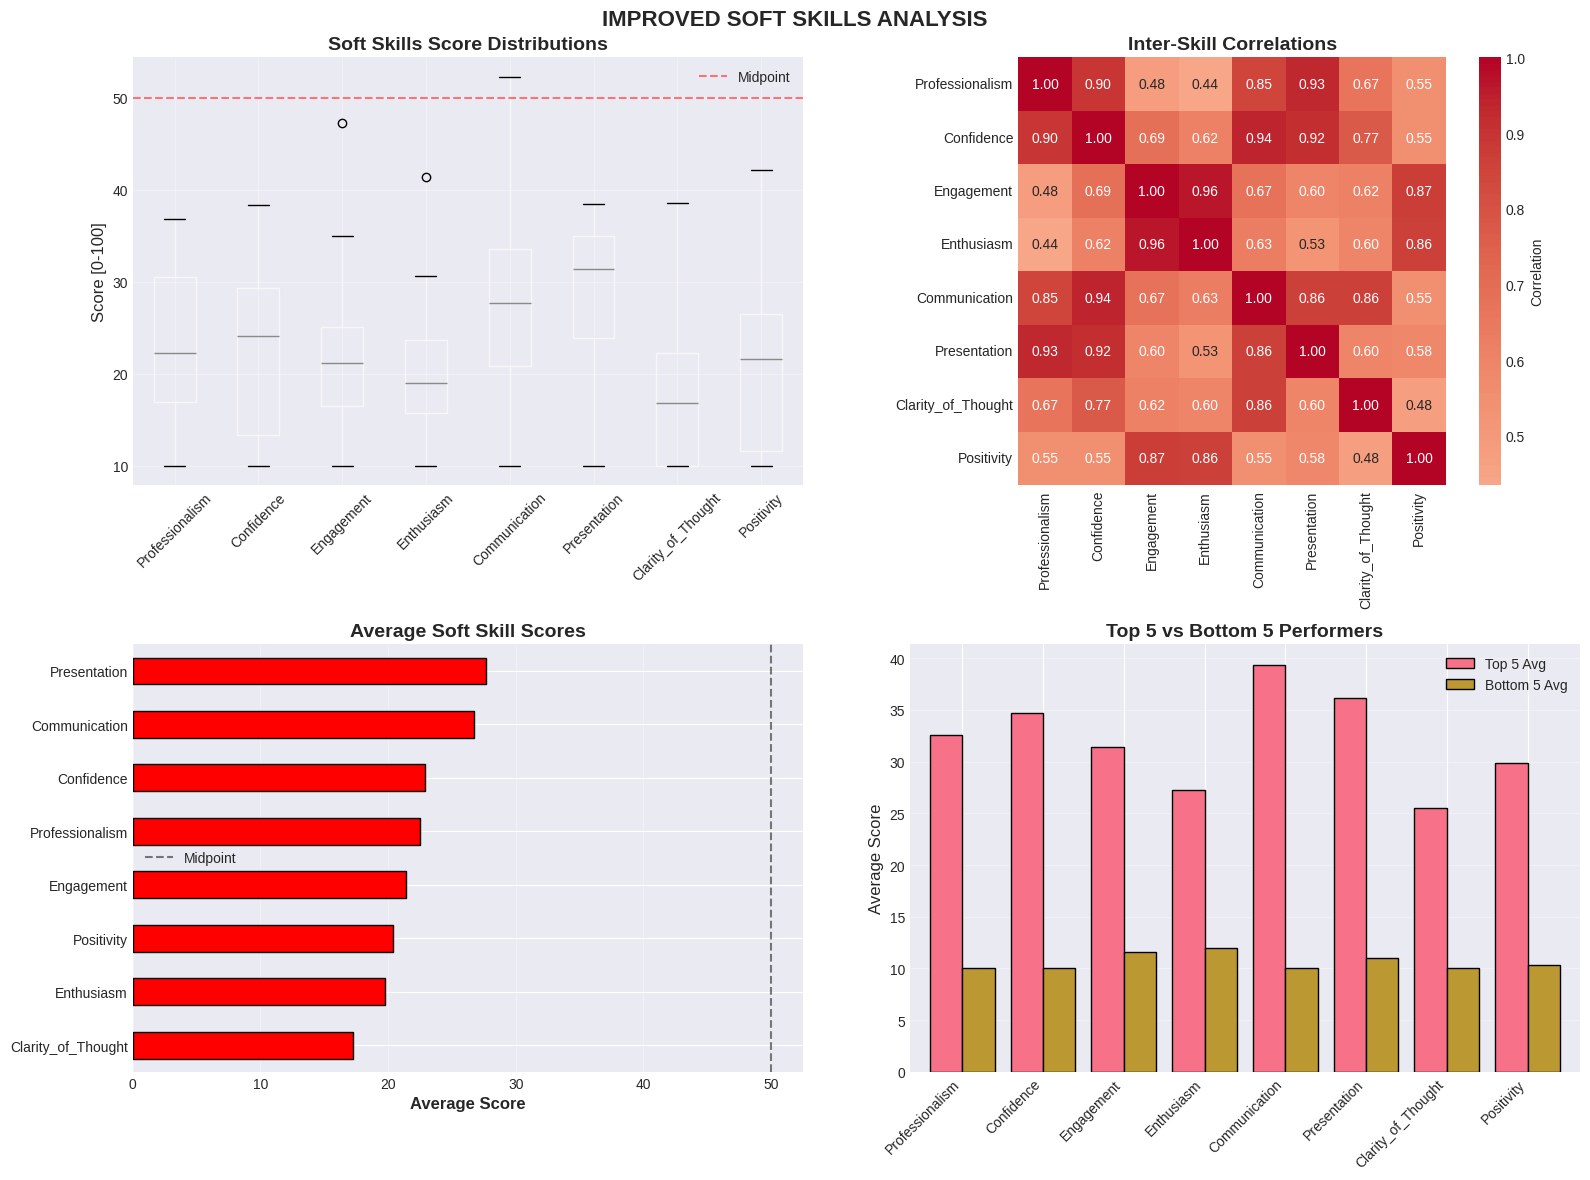

Visualizations saved to: improved_soft_skills_analysis.png


In [15]:
visualize_soft_skills(soft_skills_df, merged_df)

## Modeling Strategy

### Models Evaluated

| Category | Models |
|--------|-------|
| Linear (regularized) | Ridge, Lasso, ElasticNet |
| Probabilistic | Bayesian Ridge |
| Non-linear | Random Forest, SVR (linear & RBF) |

### Evaluation Protocol
- **Leave-One-Out Cross-Validation (LOOCV)**
- Metrics:
  - R² (train & test)
  - RMSE
  - MAE
  - Overfitting gap = Train R² − Test R²

This is intentionally strict due to **small dataset size**.

In [16]:
def get_models_with_explanations():
    models = {
        # LINEAR MODELS WITH REGULARIZATION
        'Ridge_α1': {
            'model': Ridge(alpha=1.0, random_state=42)  #L2 regularization, mild penalty
        },
        'Ridge_α10': {
            'model': Ridge(alpha=10.0, random_state=42) #L2 regularization, moderate penalty
        },
        'Ridge_α100': {
            'model': Ridge(alpha=100.0, random_state=42) #L2 regularization, strong penalty
        },
        'Lasso_α0.1': {
            'model': Lasso(alpha=0.1, random_state=42, max_iter=10000)   #L1 regularization, feature selection
        },
        'Lasso_α1.0': {
            'model': Lasso(alpha=1.0, random_state=42, max_iter=10000)  #L1 regularization, strong feature selection
        },
        'ElasticNet_α1': {
            'model': ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=42, max_iter=10000)
        },
        'BayesianRidge': {
            'model': BayesianRidge(compute_score=True) #Probabilistic, automatic regularization
        },

        # NON-LINEAR MODELS
        'RandomForest_shallow': {
            'model': RandomForestRegressor(
                n_estimators=50,
                max_depth=3,  # Shallow trees prevent overfitting
                min_samples_leaf=3,  # At least 3 samples per leaf
                random_state=42
            )
        },
        'SVR_linear': {
            'model': SVR(kernel='linear', C=1.0)
        },
        'SVR_rbf_weak': {
            'model': SVR(kernel='rbf', C=0.1, gamma='scale') #weak C (less overfitting)
        }
    }
    return models

models_dict = get_models_with_explanations()

In [17]:
print("   • High alpha values (Ridge/Lasso) = stronger regularization")
print("   • Shallow trees (max_depth=3) = prevent memorization")
print("   • Low C values (SVR) = simpler decision boundaries")
print("   • Leave-One-Out CV = most honest evaluation for small data")

   • High alpha values (Ridge/Lasso) = stronger regularization
   • Shallow trees (max_depth=3) = prevent memorization
   • Low C values (SVR) = simpler decision boundaries
   • Leave-One-Out CV = most honest evaluation for small data


In [18]:
soft_skills = [
    'Professionalism', 'Confidence', 'Engagement', 'Enthusiasm',
    'Communication', 'Presentation', 'Clarity_of_Thought', 'Positivity'
]



---

## Model Selection

For each soft skill:
- Models are ranked by  
  **Test R² − 0.5 × Overfitting Gap**
- Best model per skill is stored

### Outputs

| File | Contents |
|----|---------|
| `original_soft_skills_labels.csv` | Final soft-skill scores |
| `soft_skills_detailed_results.csv` | All model metrics |
| `soft_skills_best_models.csv` | Best model per skill |




In [19]:
# Initialize results storage
all_results = []
loocv = LeaveOneOut()

for skill_idx, skill in enumerate(soft_skills):
    print(f"ANALYZING: {skill} ({skill_idx+1}/{len(soft_skills)})")

    # Select features for this skill
    selected_features = feature_importance[skill]

    X = merged_df[selected_features].values
    y = soft_skills_df[skill].values

    print(f"Features: {selected_features}")
    print(f"Samples: {len(y)} | Features: {X.shape[1]}")

    for model_name, model_info in models_dict.items():
        # Create pipeline with scaling
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model_info['model'])
        ])

        # LOOCV predictions (test set)
        y_pred_test = cross_val_predict(pipeline, X, y, cv=loocv, n_jobs=-1)

        # Calculate test metrics
        test_r2 = r2_score(y, y_pred_test)
        test_rmse = np.sqrt(mean_squared_error(y, y_pred_test))
        test_mae = mean_absolute_error(y, y_pred_test)

        # Get training scores (each fold's training R²)
        train_scores = []
        for train_idx, test_idx in loocv.split(X):
            X_train, y_train = X[train_idx], y[train_idx]
            pipeline_fit = Pipeline([
                ('scaler', StandardScaler()),
                ('model', model_info['model'])
            ])
            pipeline_fit.fit(X_train, y_train)
            train_r2 = pipeline_fit.score(X_train, y_train)
            train_scores.append(train_r2)

        avg_train_r2 = np.mean(train_scores)
        overfitting_gap = avg_train_r2 - test_r2

        # Store results
        all_results.append({
            'Skill': skill,
            'Model': model_name,
            'Train_R2': avg_train_r2,
            'Test_R2': test_r2,
            'Test_RMSE': test_rmse,
            'Test_MAE': test_mae,
            'Overfitting_Gap': overfitting_gap
        })

        # Visual indicator for overfitting
        if overfitting_gap < 0.1:
            indicator = "GOOD"
        elif overfitting_gap < 0.3:
            indicator = "MILD"
        else:
            indicator = "HIGH"

        print(f"  {model_name:25} | Train R²: {avg_train_r2:6.3f} | "
              f"Test R²: {test_r2:6.3f} | Gap: {overfitting_gap:6.3f} {indicator}")

# Convert to DataFrame
results_df = pd.DataFrame(all_results)

ANALYZING: Professionalism (1/8)
Features: ['eye_focus_class(0-2)_numeric', 'posture_class(0-2)_numeric', 'no_of_filler_words', 'loudness_mean']
Samples: 32 | Features: 4
  Ridge_α1                  | Train R²:  0.716 | Test R²:  0.548 | Gap:  0.168 MILD
  Ridge_α10                 | Train R²:  0.693 | Test R²:  0.558 | Gap:  0.135 MILD
  Ridge_α100                | Train R²:  0.422 | Test R²:  0.340 | Gap:  0.082 GOOD
  Lasso_α0.1                | Train R²:  0.716 | Test R²:  0.559 | Gap:  0.157 MILD
  Lasso_α1.0                | Train R²:  0.673 | Test R²:  0.611 | Gap:  0.062 GOOD
  ElasticNet_α1             | Train R²:  0.642 | Test R²:  0.559 | Gap:  0.083 GOOD
  BayesianRidge             | Train R²:  0.713 | Test R²:  0.553 | Gap:  0.159 MILD
  RandomForest_shallow      | Train R²:  0.752 | Test R²:  0.491 | Gap:  0.262 MILD
  SVR_linear                | Train R²:  0.662 | Test R²:  0.496 | Gap:  0.166 MILD
  SVR_rbf_weak              | Train R²:  0.085 | Test R²:  0.060 | Gap:  

In [20]:
best_models_summary = []

for skill in soft_skills:
    skill_data = results_df[results_df['Skill'] == skill].copy()

    # Sort by test R² (descending) and overfitting gap (ascending)
    skill_data['score'] = skill_data['Test_R2'] - 0.5 * skill_data['Overfitting_Gap']
    skill_data = skill_data.sort_values('score', ascending=False)

    best = skill_data.iloc[0]

    best_models_summary.append({
        'Skill': skill,
        'Best_Model': best['Model'],
        'Test_R2': best['Test_R2'],
        'Overfitting_Gap': best['Overfitting_Gap']
    })

    print(f"{skill:25} | {best['Model']:25} | "
          f"Test R²: {best['Test_R2']:6.3f} | Gap: {best['Overfitting_Gap']:6.3f}")

best_summary_df = pd.DataFrame(best_models_summary)

Professionalism           | Lasso_α1.0                | Test R²:  0.611 | Gap:  0.062
Confidence                | Ridge_α10                 | Test R²:  0.646 | Gap:  0.079
Engagement                | Lasso_α0.1                | Test R²:  0.565 | Gap:  0.284
Enthusiasm                | SVR_linear                | Test R²:  0.521 | Gap:  0.036
Communication             | RandomForest_shallow      | Test R²:  0.709 | Gap:  0.127
Presentation              | BayesianRidge             | Test R²:  0.773 | Gap:  0.057
Clarity_of_Thought        | SVR_linear                | Test R²:  0.665 | Gap:  0.032
Positivity                | Lasso_α1.0                | Test R²:  0.724 | Gap:  0.039


In [21]:
from sklearn.base import clone
def plot_learning_curve_for_skill(skill, X, y, model_name, model):
    from sklearn.model_selection import learning_curve, KFold

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    # Use KFold instead of LOOCV for learning curves (more stable)
    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    # Calculate learning curves using sklearn's built-in function
    train_sizes_abs, train_scores, test_scores = learning_curve(
        pipeline, X, y,
        train_sizes=np.linspace(0.2, 1.0, 8),  # 20% to 100% of data
        cv=cv,
        scoring='r2',
        n_jobs=-1,
        random_state=42
    )

    # Calculate mean and std
    train_r2_mean = train_scores.mean(axis=1)
    train_r2_std = train_scores.std(axis=1)
    test_r2_mean = test_scores.mean(axis=1)
    test_r2_std = test_scores.std(axis=1)

    # Calculate RMSE learning curves
    train_rmse_mean = []
    test_rmse_mean = []

    for train_size in train_sizes_abs:
        train_rmse_folds = []
        test_rmse_folds = []

        for train_idx, test_idx in cv.split(X):
            # Sample the specified train_size
            if len(train_idx) > train_size:
                train_idx = np.random.choice(train_idx, size=train_size, replace=False)

            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            # Clone and fit pipeline
            from sklearn.base import clone
            pipeline_copy = clone(pipeline)
            pipeline_copy.fit(X_train, y_train)

            # Calculate RMSE
            y_train_pred = pipeline_copy.predict(X_train)
            y_test_pred = pipeline_copy.predict(X_test)

            train_rmse_folds.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
            test_rmse_folds.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))

        train_rmse_mean.append(np.mean(train_rmse_folds))
        test_rmse_mean.append(np.mean(test_rmse_folds))

    return (train_sizes_abs,
            train_r2_mean,
            test_r2_mean,
            np.array(train_rmse_mean),
            np.array(test_rmse_mean))

In [22]:
# Select one representative skill for detailed visualization
demo_skill = 'Clarity_of_Thought'
demo_features = feature_importance[demo_skill]

# Get data for demo skill
np.random.seed(42)
X_demo = merged_df[demo_features].values
y_demo = soft_skills_df[demo_skill].values

In [23]:
# Filter results for the demo skill
clarity_data = results_df[results_df['Skill'] == demo_skill].sort_values('Test_R2', ascending=False)

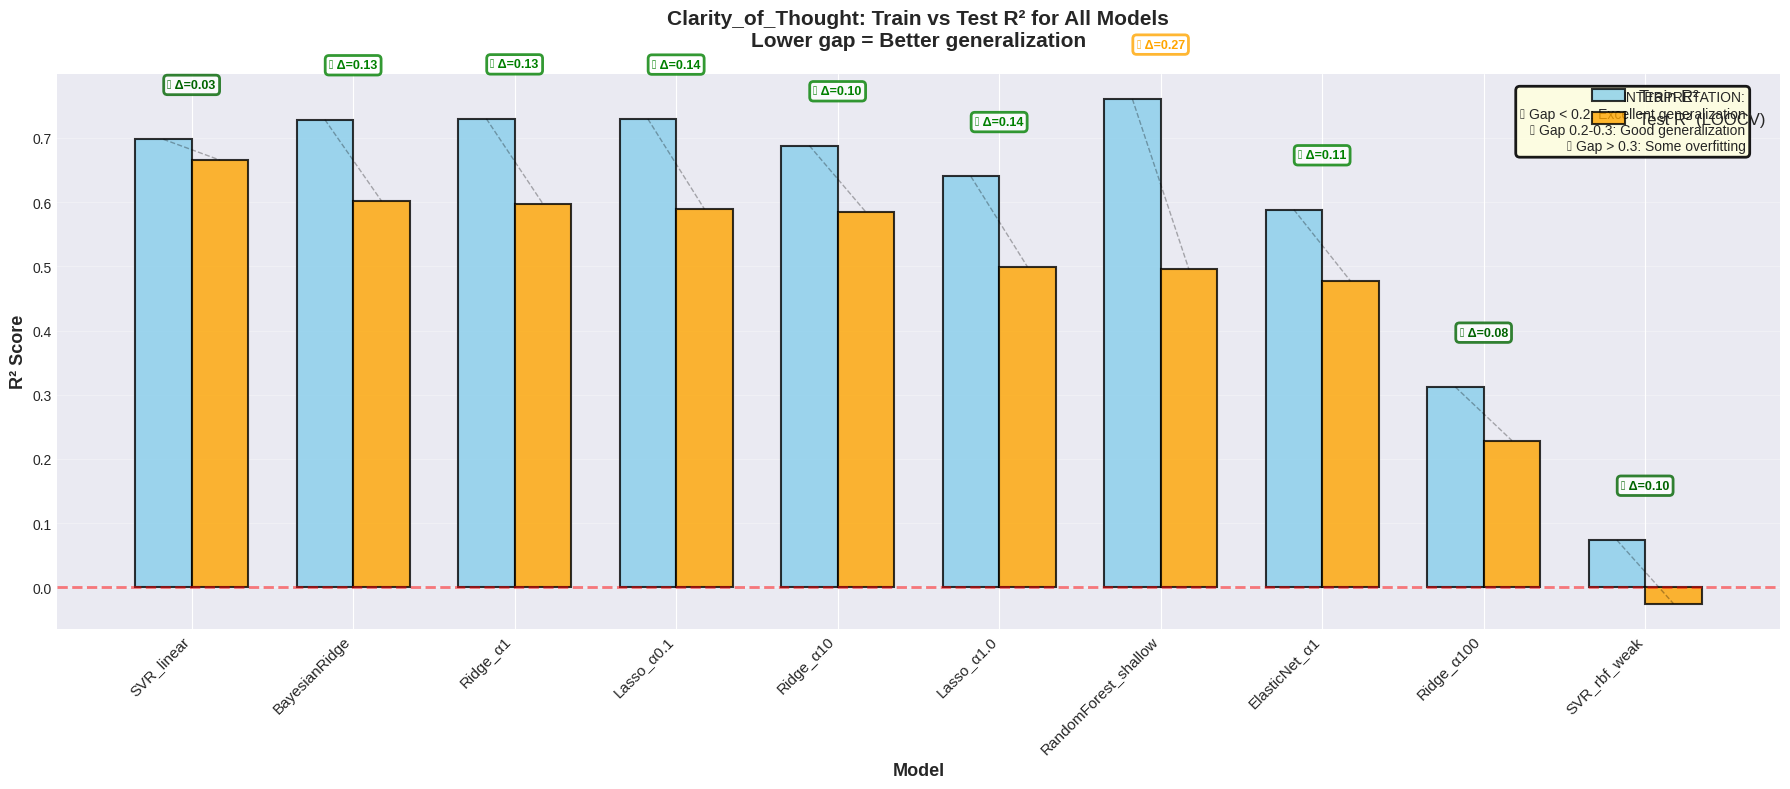

In [24]:
# Create figure
fig, ax = plt.subplots(1, 1, figsize=(18, 8))

x_pos = np.arange(len(clarity_data))
width = 0.35

# Plot bars
bars1 = ax.bar(x_pos - width/2, clarity_data['Train_R2'], width,
               label='Train R²', alpha=0.8, color='skyblue', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x_pos + width/2, clarity_data['Test_R2'], width,
               label='Test R² (LOOCV)', alpha=0.8, color='orange', edgecolor='black', linewidth=1.5)

# Styling
ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=13, fontweight='bold')
ax.set_title(f'{demo_skill}: Train vs Test R² for All Models\n'
             f'Lower gap = Better generalization',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x_pos)
ax.set_xticklabels(clarity_data['Model'], rotation=45, ha='right', fontsize=11)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=2, label='Zero baseline')

# Add overfitting gap annotations
for i, (idx, row) in enumerate(clarity_data.iterrows()):
    gap = row['Overfitting_Gap']

    # Color based on gap size
    if gap < 0.1:
        color = 'darkgreen'
        label = '✓'
    elif gap < 0.2:
        color = 'green'
        label = '✓'
    elif gap < 0.3:
        color = 'orange'
        label = '⚠'
    else:
        color = 'red'
        label = '✗'

    # Add gap annotation above bars
    y_pos = max(row['Train_R2'], row['Test_R2']) + 0.08
    ax.text(i, y_pos, f'{label} Δ={gap:.2f}',
            ha='center', fontsize=9, color=color, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                     edgecolor=color, linewidth=2, alpha=0.8))

    # Add connecting line between train and test bars
    ax.plot([i - width/2, i + width/2],
            [row['Train_R2'], row['Test_R2']],
            'k--', alpha=0.3, linewidth=1)

# Add interpretation box
interpretation_text = (
    "INTERPRETATION:\n"
    "✓ Gap < 0.2: Excellent generalization\n"
    "⚠ Gap 0.2-0.3: Good generalization\n"
    "✗ Gap > 0.3: Some overfitting"
)
ax.text(0.98, 0.97, interpretation_text, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9,
                 edgecolor='black', linewidth=2))

plt.tight_layout()
plt.savefig('01_train_vs_test_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Learning Curve Analysis

For a representative skill:
- Learning curves (R² and RMSE) are plotted
- Uses K-Fold CV for stability
- Shows:
  - Data sufficiency
  - Bias vs variance behavior
  - Whether more data would help


   Generating learning curve for SVR_linear...

   Generating learning curve for BayesianRidge...

   Generating learning curve for Ridge_α1...


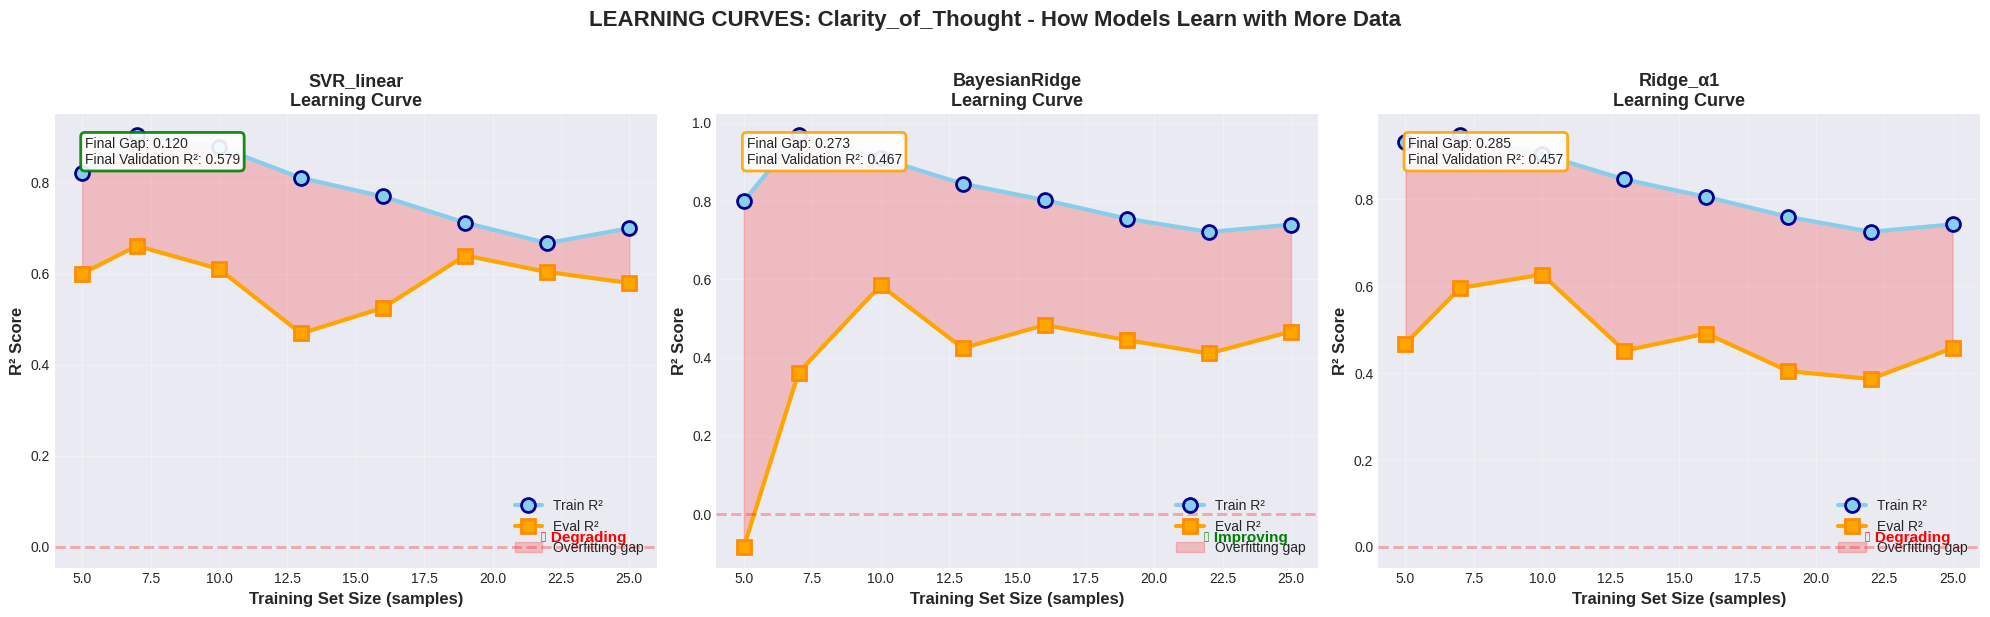

In [25]:
# Get top 3 models
top_3_models = clarity_data.head(3)

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (_, model_row) in enumerate(top_3_models.iterrows()):
    ax = axes[idx]

    model_name = model_row['Model']
    model_obj = models_dict[model_name]['model']

    print(f"\n   Generating learning curve for {model_name}...")

    # Generate learning curve
    sizes, train_r2, test_r2, train_rmse, test_rmse = plot_learning_curve_for_skill(
        demo_skill, X_demo, y_demo, model_name, model_obj
    )

    # Plot R² curves
    ax.plot(sizes, train_r2, 'o-', label='Train R²', linewidth=3,
            markersize=10, color='skyblue', markeredgecolor='darkblue', markeredgewidth=2)
    ax.plot(sizes, test_r2, 's-', label='Eval R²', linewidth=3,
            markersize=10, color='orange', markeredgecolor='darkorange', markeredgewidth=2)

    # Fill area between curves (shows overfitting gap)
    ax.fill_between(sizes, train_r2, test_r2, alpha=0.2, color='red',
                     label='Overfitting gap')

    # Styling
    ax.set_xlabel('Training Set Size (samples)', fontsize=12, fontweight='bold')
    ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
    ax.set_title(f'{model_name}\nLearning Curve', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3, linewidth=2)

    # Add final gap annotation
    final_gap = train_r2[-1] - test_r2[-1]
    gap_color = 'green' if final_gap < 0.2 else 'orange' if final_gap < 0.3 else 'red'

    ax.text(0.05, 0.95,
            f'Final Gap: {final_gap:.3f}\n'
            f'Final Validation R²: {test_r2[-1]:.3f}',
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round', facecolor='white',
                     edgecolor=gap_color, linewidth=2, alpha=0.9))

    # Add trend arrows
    if test_r2[-1] > test_r2[0]:
        trend = "↗ Improving"
        trend_color = "green"
    elif test_r2[-1] < test_r2[0]:
        trend = "↘ Degrading"
        trend_color = "red"
    else:
        trend = "→ Stable"
        trend_color = "orange"

    ax.text(0.95, 0.05, trend, transform=ax.transAxes,
            fontsize=11, va='bottom', ha='right', color=trend_color,
            fontweight='bold')

plt.suptitle(f'LEARNING CURVES: {demo_skill} - How Models Learn with More Data',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('02_learning_curves_r2.png', dpi=300, bbox_inches='tight')
plt.show()

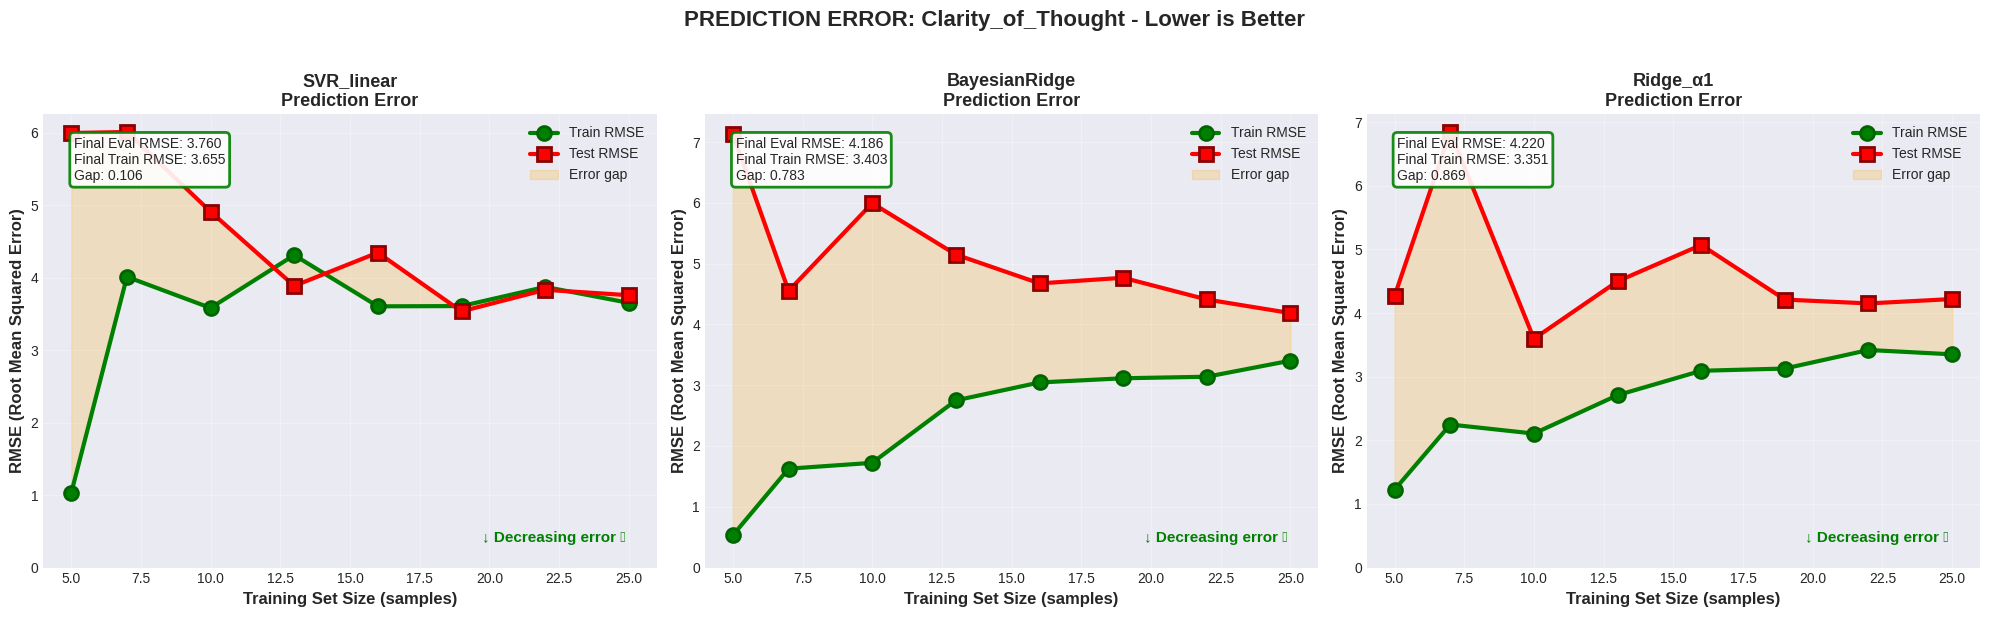

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (_, model_row) in enumerate(top_3_models.iterrows()):
    ax = axes[idx]

    model_name = model_row['Model']
    model_obj = models_dict[model_name]['model']

    # Generate learning curve (reuse from previous cell)
    sizes, train_r2, test_r2, train_rmse, test_rmse = plot_learning_curve_for_skill(
        demo_skill, X_demo, y_demo, model_name, model_obj
    )

    # Plot RMSE curves
    ax.plot(sizes, train_rmse, 'o-', label='Train RMSE', linewidth=3,
            markersize=10, color='green', markeredgecolor='darkgreen', markeredgewidth=2)
    ax.plot(sizes, test_rmse, 's-', label='Test RMSE', linewidth=3,
            markersize=10, color='red', markeredgecolor='darkred', markeredgewidth=2)

    # Fill area between curves
    ax.fill_between(sizes, train_rmse, test_rmse, alpha=0.2, color='orange',
                     label='Error gap')

    # Styling
    ax.set_xlabel('Training Set Size (samples)', fontsize=12, fontweight='bold')
    ax.set_ylabel('RMSE (Root Mean Squared Error)', fontsize=12, fontweight='bold')
    ax.set_title(f'{model_name}\nPrediction Error', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)

    # Add final RMSE annotation
    final_test_rmse = test_rmse[-1]
    final_train_rmse = train_rmse[-1]
    rmse_gap = final_test_rmse - final_train_rmse

    rmse_color = 'green' if final_test_rmse < 5 else 'orange' if final_test_rmse < 10 else 'red'

    ax.text(0.05, 0.95,
            f'Final Eval RMSE: {final_test_rmse:.3f}\n'
            f'Final Train RMSE: {final_train_rmse:.3f}\n'
            f'Gap: {rmse_gap:.3f}',
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round', facecolor='white',
                     edgecolor=rmse_color, linewidth=2, alpha=0.9))

    # Add error trend
    if test_rmse[-1] < test_rmse[0]:
        trend = "↓ Decreasing error ✓"
        trend_color = "green"
    elif test_rmse[-1] > test_rmse[0]:
        trend = "↑ Increasing error ✗"
        trend_color = "red"
    else:
        trend = "→ Stable error"
        trend_color = "orange"

    ax.text(0.95, 0.05, trend, transform=ax.transAxes,
            fontsize=11, va='bottom', ha='right', color=trend_color,
            fontweight='bold')

    # Set y-axis to start from 0 for better comparison
    ax.set_ylim(bottom=0)

plt.suptitle(f'PREDICTION ERROR: {demo_skill} - Lower is Better',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('03_learning_curves_rmse.png', dpi=300, bbox_inches='tight')
plt.show()

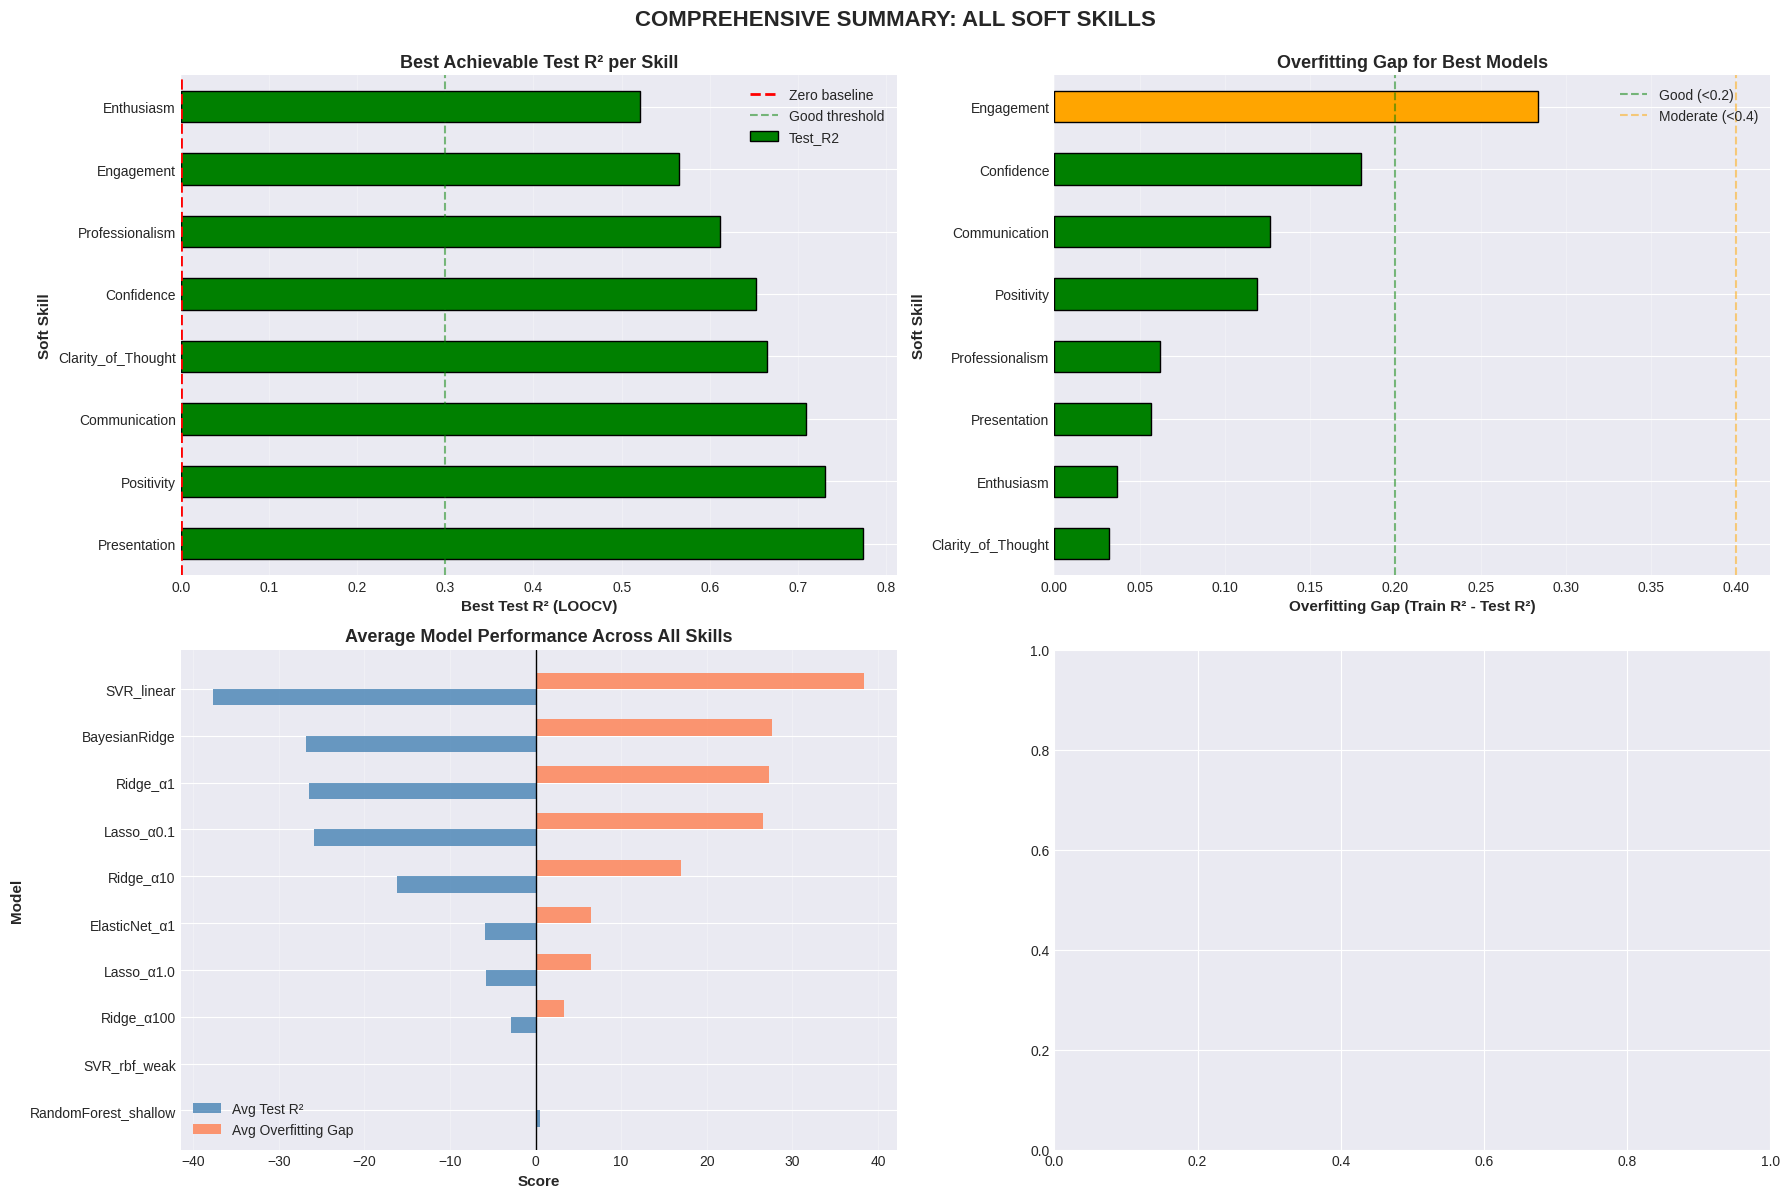

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Best Test R² per skill
ax1 = axes[0, 0]
best_test_r2 = results_df.groupby('Skill')['Test_R2'].max().sort_values(ascending=False)
colors_r2 = ['green' if x > 0.3 else 'orange' if x > 0 else 'red' for x in best_test_r2]
best_test_r2.plot(kind='barh', ax=ax1, color=colors_r2, edgecolor='black')
ax1.set_xlabel('Best Test R² (LOOCV)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Soft Skill', fontsize=11, fontweight='bold')
ax1.set_title('Best Achievable Test R² per Skill', fontsize=13, fontweight='bold')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero baseline')
ax1.axvline(x=0.3, color='green', linestyle='--', alpha=0.5, label='Good threshold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: Overfitting Gap per skill (best models)
ax2 = axes[0, 1]
best_gaps = []
for skill in soft_skills:
    skill_data = results_df[results_df['Skill'] == skill]
    best_idx = skill_data['Test_R2'].idxmax()
    best_gaps.append(skill_data.loc[best_idx, 'Overfitting_Gap'])

gap_series = pd.Series(best_gaps, index=soft_skills).sort_values()
colors_gap = ['green' if x < 0.2 else 'orange' if x < 0.4 else 'red' for x in gap_series]
gap_series.plot(kind='barh', ax=ax2, color=colors_gap, edgecolor='black')
ax2.set_xlabel('Overfitting Gap (Train R² - Test R²)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Soft Skill', fontsize=11, fontweight='bold')
ax2.set_title('Overfitting Gap for Best Models', fontsize=13, fontweight='bold')
ax2.axvline(x=0.2, color='green', linestyle='--', alpha=0.5, label='Good (<0.2)')
ax2.axvline(x=0.4, color='orange', linestyle='--', alpha=0.5, label='Moderate (<0.4)')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='x')

# Plot 3: Model performance comparison (average across skills)
ax3 = axes[1, 0]
model_avg = results_df.groupby('Model').agg({
    'Test_R2': 'mean',
    'Overfitting_Gap': 'mean'
}).sort_values('Test_R2', ascending=False)

x_pos = np.arange(len(model_avg))
width = 0.35

ax3.barh(x_pos - width/2, model_avg['Test_R2'], width, label='Avg Test R²', alpha=0.8, color='steelblue')
ax3.barh(x_pos + width/2, model_avg['Overfitting_Gap'], width, label='Avg Overfitting Gap', alpha=0.8, color='coral')
ax3.set_yticks(x_pos)
ax3.set_yticklabels(model_avg.index)
ax3.set_xlabel('Score', fontsize=11, fontweight='bold')
ax3.set_ylabel('Model', fontsize=11, fontweight='bold')
ax3.set_title('Average Model Performance Across All Skills', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='x')
ax3.axvline(x=0, color='black', linestyle='-', linewidth=1)


plt.suptitle('COMPREHENSIVE SUMMARY: ALL SOFT SKILLS', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('soft_skills_summary_all.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
# Export detailed results
results_df.to_csv('soft_skills_detailed_results.csv', index=False)
best_summary_df.to_csv('soft_skills_best_models.csv', index=False)

print("   • soft_skills_detailed_results.csv")
print("   • soft_skills_best_models.csv")
print("   • soft_skills_overfitting_analysis.png")
print("   • soft_skills_summary_all.png")

   • soft_skills_detailed_results.csv
   • soft_skills_best_models.csv
   • soft_skills_overfitting_analysis.png
   • soft_skills_summary_all.png



## Final Summary

This notebook:
- Converts raw **audio + video signals** into **human-interpretable soft skills**
- Validates them statistically and visually
- Trains **well-regularized models** under strict evaluation
- Produces **explainable, deployable outputs**

It forms a **core scoring and learning component** for automated interview and CV-based job recommendation systems.

---
